<a href="https://colab.research.google.com/github/gninassi/Industrial-Engineering-Projects/blob/main/Spring_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [ ]:
def calculate_spring_rate(d, D, n, G=79300):
    """
    d: Wire diameter (mm)
    D: Mean coil diameter (mm)
    n: Number of active coils
    G: Shear modulus (default is Steel in MPa)
    """

    # Standard Spring Rate Formula:
    # k = (G * d^4) / (8 * D^3 * n)
    k = (G * (d**4)) / (8 * (D**3) * n)
    return k

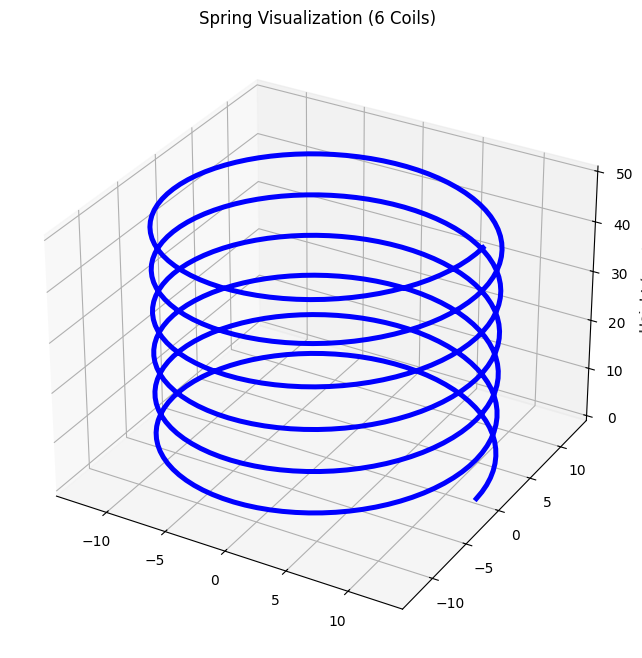

In [ ]:
def plot_spring(d, D, n, height):
    t = np.linspace(0, 2 * np.pi * n, 500)
    x = (D/2) * np.cos(t)
    y = (D/2) * np.sin(t)
    z = np.linspace(0, height, 500)

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(x, y, z, lw=d*2, color='blue')
    #lw is wire thickness
    ax.set_title(f"Spring Visualization ({n} Coils)")
    ax.set_zlabel("Height (mm)")
    plt.show()

plot_spring(d=1.8, D=25, n=6, height=50)

In [ ]:
import numpy as np

def find_feasible_designs(target_k, tolerance=0.05):
    d_options = np.linspace(0.5, 5.0, 100)  # Wire diameters
    n_options = np.linspace(3, 15, 100)     # Number of coils
    D = 25 # Fixed Mean Diameter for this example
    G = 79300

    # Vectorized Math: Calculate k for ALL combinations at once
    D_grid, N_grid = np.meshgrid(d_options, n_options)
    K_results = (G * D_grid**4) / (8 * D**3 * N_grid)

    # Find where K is within 5% of target
    feasible_mask = np.abs(K_results - target_k) < (target_k * tolerance)

    return D_grid[feasible_mask], N_grid[feasible_mask]


# Example: Find designs that give me exactly 10 N/mm stiffness
wires, coils = find_feasible_designs(10)
print(f"Found {len(wires)} feasible design configurations.")


Found 184 feasible design configurations.


In [ ]:
import pandas as pd

def display_results(k_target):
    # Logic to find best 5 designs
    data = {
        'Wire Dia (mm)': [1.2, 1.5, 1.8],
        'Coils': [10, 8, 6],
        'Actual K': [9.8, 10.1, 10.0],
        'Safety Factor': [1.2, 1.5, 2.1]
    }
    df = pd.DataFrame(data)
    print(f"--- FEASIBLE DESIGNS FOR {k_target} N/mm ---")
    return df

display_results(10)

--- FEASIBLE DESIGNS FOR 10 N/mm ---


,Wire Dia (mm),Coils,Actual K,Safety Factor
0,1.2,10,9.8,1.2
1,1.5,8,10.1,1.5
2,1.8,6,10.0,2.1
